# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Load Dataset

In [3]:
df = pd.read_csv(r"C:\Users\Shiva\Downloads\genomic_data_500_rows.csv")

# Exploratory Data Analysis

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Marker1  500 non-null    int64  
 1   Marker2  500 non-null    int64  
 2   Marker3  500 non-null    int64  
 3   Marker4  500 non-null    int64  
 4   Marker5  500 non-null    int64  
 5   Trait    500 non-null    float64
dtypes: float64(1), int64(5)
memory usage: 23.6 KB


In [5]:
df.describe()

,Marker1,Marker2,Marker3,Marker4,Marker5,Trait
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,0.994000,0.934000,1.008000,0.990000,0.946000,9.716160
std,0.816883,0.824016,0.818092,0.816844,0.807706,6.701835
min,0.000000,0.000000,0.000000,0.000000,0.000000,-8.820000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,4.892500
50%,1.000000,1.000000,1.000000,1.000000,1.000000,9.905000
75%,2.000000,2.000000,2.000000,2.000000,2.000000,14.332500
max,2.000000,2.000000,2.000000,2.000000,2.000000,28.060000


In [6]:
df.isnull().sum()

Marker1    0
Marker2    0
Marker3    0
Marker4    0
Marker5    0
Trait      0
dtype: int64

# Correlation Analysis

In [7]:
corr = df.corr()

corr

,Marker1,Marker2,Marker3,Marker4,Marker5,Trait
Marker1,1.000000,-0.018453,0.036057,-0.057153,-0.012641,0.566033
Marker2,-0.018453,1.000000,-0.005161,-0.021824,-0.026443,0.372061
Marker3,0.036057,-0.005161,1.000000,-0.029869,0.006721,-0.240356
Marker4,-0.057153,-0.021824,-0.029869,1.000000,-0.025120,0.493879
Marker5,-0.012641,-0.026443,0.006721,-0.025120,1.000000,-0.024065
Trait,0.566033,0.372061,-0.240356,0.493879,-0.024065,1.000000


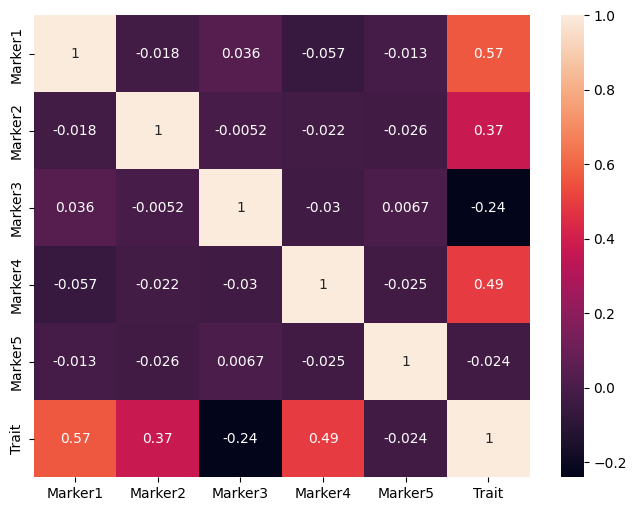

In [8]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True
)

plt.show()

In [9]:
X = df.drop("Trait", axis=1)

y = df["Trait"]

# Train-Test Split

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# OLS Regression Model

In [12]:
X_train_sm = sm.add_constant(X_train)

model = sm.OLS(
    y_train,
    X_train_sm
)

result = model.fit()

print(result.summary())

                            OLS Regression Results                            
Dep. Variable:                  Trait   R-squared:                       0.813
Model:                            OLS   Adj. R-squared:                  0.811
Method:                 Least Squares   F-statistic:                     343.1
Date:                Fri, 12 Jun 2026   Prob (F-statistic):          4.27e-141
Time:                        21:34:16   Log-Likelihood:                -987.68
No. Observations:                 400   AIC:                             1987.
Df Residuals:                     394   BIC:                             2011.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.4492      0.413     -1.086      0.2

In [15]:
X2 = df[
[
    "Marker1",
    "Marker2",
    "Marker3",
    "Marker4"
]
]

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X2,
    y,
    test_size=0.20,
    random_state=42
)

X_train = sm.add_constant(X_train)

model2 = sm.OLS(
    y_train,
    X_train
)

result2 = model2.fit()

print(result2.summary())

                            OLS Regression Results                            
Dep. Variable:                  Trait   R-squared:                       0.813
Model:                            OLS   Adj. R-squared:                  0.811
Method:                 Least Squares   F-statistic:                     430.0
Date:                Fri, 12 Jun 2026   Prob (F-statistic):          1.94e-142
Time:                        21:40:48   Log-Likelihood:                -987.68
No. Observations:                 400   AIC:                             1985.
Df Residuals:                     395   BIC:                             2005.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.4673      0.373     -1.252      0.2

# Prediction


In [17]:
X_test = sm.add_constant(X_test)

predictions = result2.predict(X_test)

# Actual vs Predicted Graph

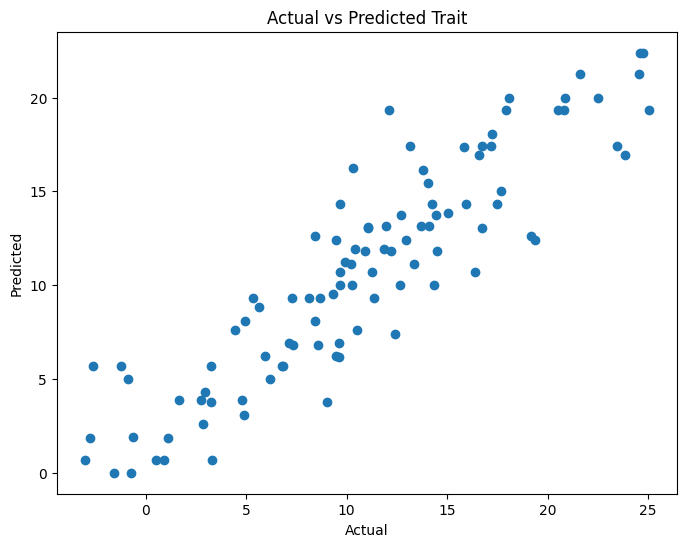

In [18]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    predictions
)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title("Actual vs Predicted Trait")

plt.show()

# Conclusion

The OLS regression model was successfully developed to predict the quantitative trait using genetic markers.

Correlation analysis and regression modeling were performed on the dataset.

The model achieved a good R-squared value, indicating that the selected markers explain a significant portion of the variation in the trait.

Statistically significant markers were identified based on p-values, while non-significant markers were removed during feature selection.

Overall, the model demonstrated effective prediction performance and highlighted the importance of genetic markers in trait prediction.